<a href="https://colab.research.google.com/github/leticiagoncalves-ship-it/geomodelagem/blob/main/acaiebarbeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.3 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "h5w9IxeDGa4sAYSb4aCw"
WORKSPACE = "letcias-workspace-masn4"
PROJECT_NAME = "acai2026"
VERSION = 3

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)


loading Roboflow workspace...
loading Roboflow project...


In [3]:
print(f"Versões disponíveis para o projeto '{project.name}':")
for v in project.versions():
    print(f"- Versão {v.version}: {v.name}")



Versões disponíveis para o projeto 'acai2026':
- Versão 1352792424: acai2026
- Versão 3: acai2026
- Versão 2: acai2026
- Versão 1: acai2026


In [4]:
version = project.version(VERSION)
dataset = version.download("yolov11")

print("Dataset baixado em:", dataset.location)



Extracting Dataset Version Zip to acai2026-3 in yolov11:: 100%|██████████| 135/135 [00:00<00:00, 3827.77it/s]

Dataset baixado em: /content/acai2026-3


In [5]:
import os
import yaml

data_yaml_path = os.path.join(dataset.location, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Remove a entrada 'path' problemática, se existir
if 'path' in data_config:
    print(f"Removendo a entrada 'path' problemática do data.yaml: {data_config['path']}")
    del data_config['path']

# Define os caminhos corretos para train, val e test
if 'train' in data_config:
    data_config['train'] = os.path.join(dataset.location, 'train')
if 'val' in data_config:
    # O Roboflow costuma nomear a pasta de validação como 'valid'
    data_config['val'] = os.path.join(dataset.location, 'valid')
if 'test' in data_config:
    data_config['test'] = os.path.join(dataset.location, 'test')

print("Classes detectadas no dataset:", data_config.get('names'))
print("Número de classes:", data_config.get('nc'))

# Salva o data.yaml ajustado
temp_data_yaml_path = os.path.join(dataset.location, 'data_modified_ultralytics.yaml')
with open(temp_data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"data.yaml modificado salvo em: {temp_data_yaml_path}")
print("Conteúdo do data.yaml modificado:")
with open(temp_data_yaml_path, 'r') as f:
    print(f.read())


Classes detectadas no dataset: ['acai2026', 'barbeiro']
Número de classes: 2
data.yaml modificado salvo em: /content/acai2026-3/data_modified_ultralytics.yaml
Conteúdo do data.yaml modificado:
names:
- acai2026
- barbeiro
nc: 2
roboflow:
  license: CC BY 4.0
  project: acai2026
  url: https://universe.roboflow.com/letcias-workspace-masn4/acai2026/dataset/3
  version: 3
  workspace: letcias-workspace-masn4
test: /content/acai2026-3/test
train: /content/acai2026-3/train
val: /content/acai2026-3/valid



In [6]:
from ultralytics import YOLO

model = YOLO("yolo11l-seg.pt")  # modelo base de segmentação

model.train(
    data=temp_data_yaml_path,
    epochs=5,
    imgsz=640,
    batch=16,
    workers=8,
    project=PROJECT_NAME,
    name="exp_acai_barbeiro"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acai2026-3/data_modified_ultralytics.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf5a4367ef0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,134 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2685.9±1055.7 MB/s, size: 139.5 KB)
val: Scanning /content/acai2026-3/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 2.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all          5         15      0.278      0.292      0.204     0.0958      0.299      0.417      0.329      0.121
              acai2026          5         12      0.247       0.25      0.151      0.119      0.151      0.167      0.129      0.064
              barbeiro          3          3       0.31      0.333      0.257     0.0722      0.447      0.667      0.529      0.177
Speed: 1.8ms preprocess, 58.1ms inference, 0.

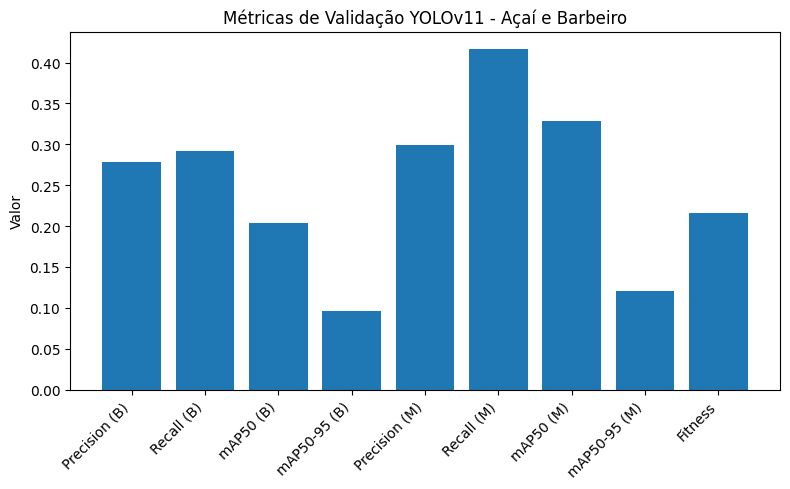

In [7]:
metrics = model.val(data=temp_data_yaml_path)
print(metrics)

import matplotlib.pyplot as plt

labels_map = {
    "metrics/precision(B)": "Precision (B)",
    "metrics/recall(B)": "Recall (B)",
    "metrics/mAP50(B)": "mAP50 (B)",
    "metrics/mAP50-95(B)": "mAP50-95 (B)",
    "metrics/precision(M)": "Precision (M)",
    "metrics/recall(M)": "Recall (M)",
    "metrics/mAP50(M)": "mAP50 (M)",
    "metrics/mAP50-95(M)": "mAP50-95 (M)",
    "fitness": "Fitness"
}

keys = list(metrics.results_dict.keys())
values = list(metrics.results_dict.values())
labels = [labels_map.get(k, k) for k in keys]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Valor")
plt.title("Métricas de Validação YOLOv11 - Açaí e Barbeiro")
plt.tight_layout()
plt.show()


Encontradas 3 imagens de teste

image 1/1 /content/acai2026-3/test/images/acai2_jpg.rf.a67a787f3bf66e7f6d9346def88d6f35.jpg: 384x640 1 acai2026, 67.2ms
Speed: 2.2ms preprocess, 67.2ms inference, 10.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/predict


array([[[ 49,  76, 110],
        [ 27,  54,  88],
        [  9,  36,  70],
        ...,
        [ 58, 143, 159],
        [ 96, 174, 190],
        [ 99, 177, 190]],

       [[ 51,  78, 112],
        [ 29,  56,  90],
        [ 11,  38,  72],
        ...,
        [ 64, 149, 165],
        [100, 178, 194],
        [101, 179, 192]],

       [[ 51,  78, 112],
        [ 29,  56,  90],
        [ 13,  40,  74],
        ...,
        [ 64, 151, 167],
        [101, 182, 197],
        [105, 184, 197]],

       ...,

       [[122, 163, 202],
        [120, 163, 202],
        [120, 162, 205],
        ...,
        [112, 161, 169],
        [110, 159, 167],
        [107, 156, 164]],

       [[122, 163, 202],
        [120, 163, 202],
        [120, 162, 205],
        ...,
        [134, 183, 191],
        [133, 182, 190],
        [132, 181, 189]],

       [[122, 163, 202],
        [120, 163, 202],
        [120, 162, 205],
        ...,
        [144, 193, 201],
        [145, 194, 202],
        [145, 194, 202]]], dtype=uint8)
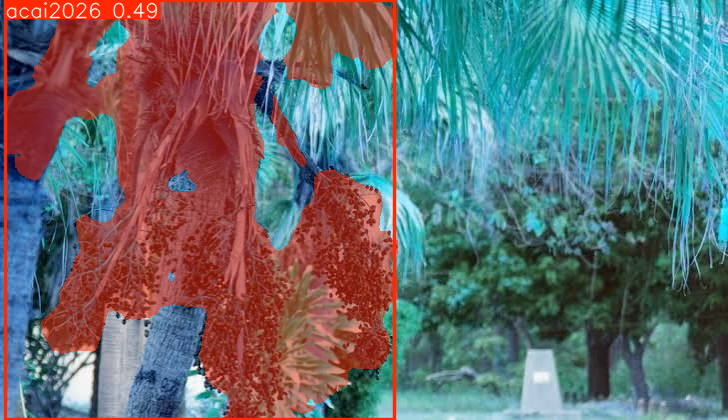

In [8]:
import glob

# Pega automaticamente a primeira imagem da pasta de teste do dataset
# (não precisa informar nenhum caminho - já usa o dataset baixado na seção 3)
test_images = glob.glob(os.path.join(dataset.location, "test", "images", "*.*"))
print(f"Encontradas {len(test_images)} imagens de teste")

results = model.predict(test_images[0], save=True)

# Mostrar máscaras/detecções (açaí e barbeiro)
results[0].plot()
